# NERVE Label Extraction Pipeline

NERVE provides **automated** RGB-space labels: object detection and instance segmentation (e.g. YOLOv8-family), human **pose** (17 COCO keypoints), per-instance **depth** from the L515 (`avg_distance`, `distance_points`), and **track IDs** for temporal consistency. This notebook inspects those fields directly from `annotations.json`.

In [1]:
from nerve import config, remote
from nerve.registry import all_sessions
from pathlib import Path

sessions = all_sessions()
smallest = min(sessions, key=lambda s: s.size_bytes)
print(f"Smallest session: {smallest.name}  "
      f"({smallest.size_bytes / 1e9:.2f} GB archive, split={smallest.split})")

session_dir = Path(remote.download_session(smallest.name))
print(f"Session directory: {session_dir}")


Smallest session: 2023-10-26_15-37-59  (0.40 GB archive, split=train)
  Session already exists: /gpfs/home5/omansour/.nerve/data/2023-10-26_15-37-59
Session directory: /gpfs/home5/omansour/.nerve/data/2023-10-26_15-37-59


## Detection and segmentation on RGB

Each COCO `annotation` can include a bounding box, category, confidence (`conf` when present), and polygonal `segmentation` masks produced by the segmentation head.

Loaded: 904 images, 10199 annotations, 80 categories


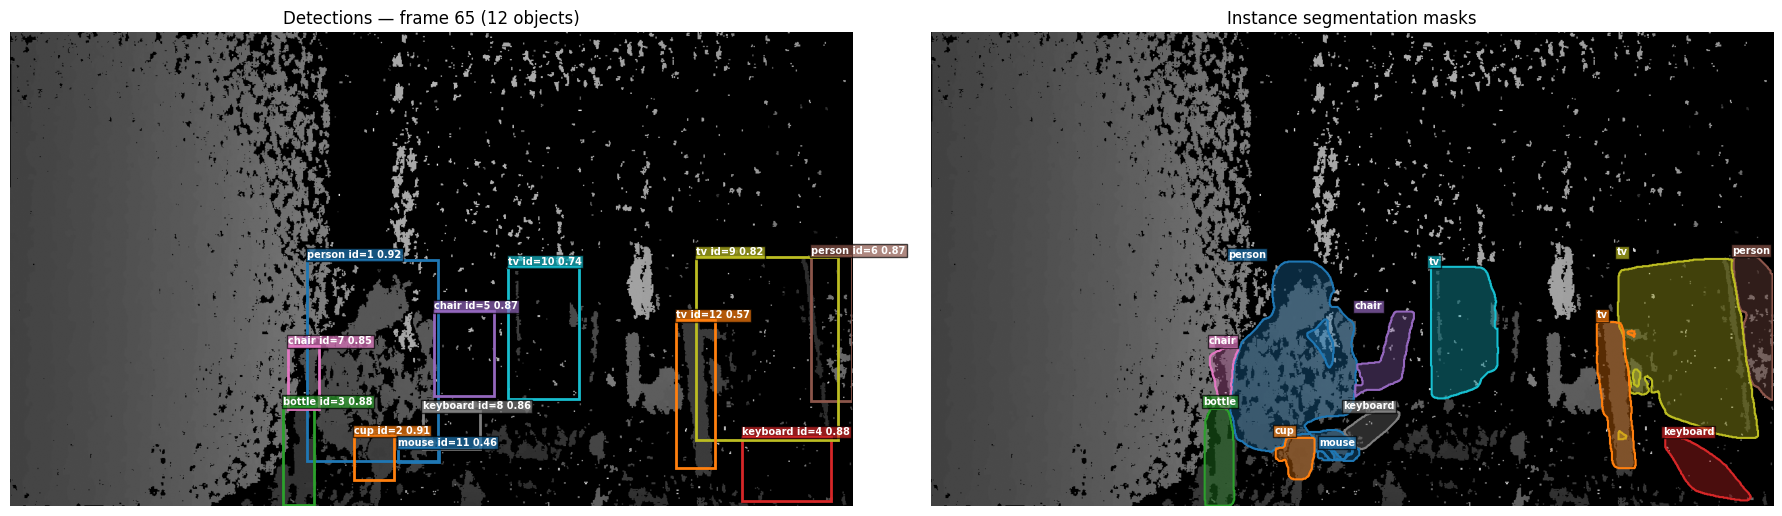


Example annotation (id=710):
  category_id: 1
  bbox: [451.44256591796875, 345.02972412109375, 199.1558837890625, 305.828857421875]
  area: 60908
  conf: 0.9196839332580566
  track_id: 1
  avg_distance: 2.190122604370117
  segmentation: 2 polygon(s)


In [15]:
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import PatchCollection
from collections import Counter

ann_path = session_dir / "rgb" / "annotations" / "annotations.json"
coco = json.loads(ann_path.read_text(encoding="utf-8"))
cat_by_id = {c["id"]: c["name"] for c in coco["categories"]}
img_by_id = {i["id"]: i for i in coco["images"]}
print(f"Loaded: {len(coco['images'])} images, "
      f"{len(coco['annotations'])} annotations, "
      f"{len(coco['categories'])} categories")

# Pick the frame with the most detections
ann_counts = Counter(a["image_id"] for a in coco["annotations"])
best_frame_id = ann_counts.most_common(1)[0][0]
frame_anns = [a for a in coco["annotations"] if a["image_id"] == best_frame_id]
img_entry = img_by_id[best_frame_id]
time_ms = img_entry["time_ms"]

# Use the depth frame as background (no RGB video in the archive)
depth_mp4 = session_dir / "L515_depth.mp4"
cap = cv2.VideoCapture(str(depth_mp4))
depth_fps = cap.get(cv2.CAP_PROP_FPS)
frame_idx = int(round(time_ms * depth_fps / 1000.0))
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
ok, bgr = cap.read()
cap.release()
bg = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY) if ok else np.zeros(
    (img_entry["height"], img_entry["width"]), dtype=np.uint8)

COLORS = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Left: bounding boxes + category labels ──
axes[0].imshow(bg, cmap="gray")
for idx, ann in enumerate(frame_anns):
    color = COLORS[idx % len(COLORS)]
    bx, by, bw, bh = ann["bbox"]
    axes[0].add_patch(patches.Rectangle((bx, by), bw, bh,
                      fill=False, edgecolor=color, linewidth=2))
    cat = cat_by_id.get(ann["category_id"], "?")
    conf = ann.get("conf", 0)
    tid = ann.get("track_id", -1)
    axes[0].text(bx, by - 3, f"{cat} id={tid} {conf:.2f}",
                 color="white", fontsize=7, weight="bold",
                 bbox=dict(facecolor=color, alpha=0.7, pad=1))
axes[0].set_title(f"Detections -- frame {best_frame_id} ({len(frame_anns)} objects)")
axes[0].axis("off")

# ── Right: segmentation masks (filled semi-transparent polygons) ──
axes[1].imshow(bg, cmap="gray")
for idx, ann in enumerate(frame_anns):
    color = COLORS[idx % len(COLORS)]
    for seg in ann.get("segmentation", []):
        pts = np.array(seg, dtype=float).reshape(-1, 2)
        poly = plt.Polygon(pts, closed=True,
                           facecolor=(*color[:3], 0.35),
                           edgecolor=color, linewidth=1.5)
        axes[1].add_patch(poly)
    cat = cat_by_id.get(ann["category_id"], "?")
    bx, by, bw, bh = ann["bbox"]
    axes[1].text(bx, by - 3, cat, color="white", fontsize=7, weight="bold",
                 bbox=dict(facecolor=color, alpha=0.7, pad=1))
axes[1].set_title("Instance segmentation masks")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Print summary of the first annotation
a = frame_anns[0]
print(f"\nExample annotation (id={a['id']}):")
for k in ["category_id", "bbox", "area", "conf", "track_id", "avg_distance"]:
    print(f"  {k}: {a.get(k, '<missing>')}")
n_seg = len(a.get("segmentation", []))
print(f"  segmentation: {n_seg} polygon(s)")


## Pose estimation -- 17 COCO keypoints

Human instances use the standard COCO keypoint layout: for each keypoint, values are `x`, `y`, `v` (visibility flag) flattened into a length-51 list.

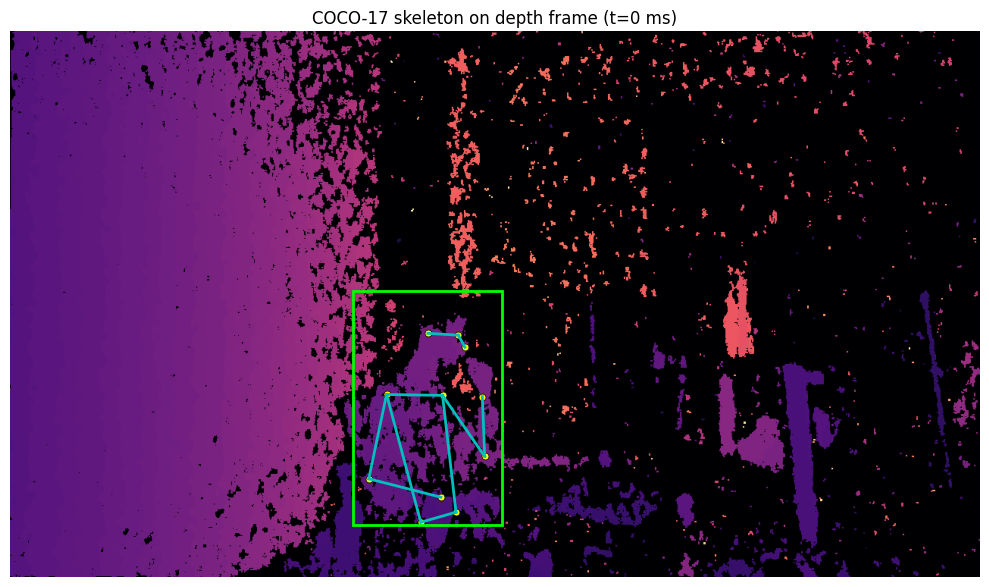

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

EDGES = [
    (0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
    (5, 11), (6, 12), (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),
]

ann_path = session_dir / "rgb" / "annotations" / "annotations.json"
coco = json.loads(ann_path.read_text(encoding="utf-8"))
img_by_id = {i["id"]: i for i in coco["images"]}

ann = next((a for a in coco["annotations"] if a.get("keypoints")), None)
if ann is None:
    raise RuntimeError("No annotation with keypoints")

img_entry = img_by_id[ann["image_id"]]
time_ms = img_entry["time_ms"]

# Use the depth frame as background
depth_mp4 = session_dir / "L515_depth.mp4"
cap = cv2.VideoCapture(str(depth_mp4))
depth_fps = cap.get(cv2.CAP_PROP_FPS)
frame_idx = int(round(time_ms * depth_fps / 1000.0))
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
ok, bgr = cap.read()
cap.release()
bg = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY) if ok else np.zeros(
    (img_entry["height"], img_entry["width"]), dtype=np.uint8)

kps = np.array(ann["keypoints"], dtype=float).reshape(-1, 3)

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(bg, cmap="magma")
for i, j in EDGES:
    if kps[i, 2] > 0.5 and kps[j, 2] > 0.5:
        ax.plot([kps[i, 0], kps[j, 0]], [kps[i, 1], kps[j, 1]], "c-", linewidth=2)
vis = kps[:, 2] > 0.5
ax.scatter(kps[vis, 0], kps[vis, 1], c="yellow", s=25, edgecolors="k", linewidths=0.5)
x, y, w, h = ann["bbox"]
ax.add_patch(patches.Rectangle((x, y), w, h, fill=False, edgecolor="lime", linewidth=2))
ax.set_title(f"COCO-17 skeleton on depth frame (t={time_ms:.0f} ms)")
ax.axis("off")
plt.tight_layout()
plt.show()


## Distance extraction (Intel L515)

Each annotation can carry two distance-related fields derived from the aligned depth stream of the Intel L515 sensor:

- **`avg_distance`** (float, metres) -- a single scalar summarising how far the detected instance is from the camera. It is computed as a **confidence-weighted average** of the depth pixels that fall inside the instance segmentation mask. Before sampling, a morphological erosion is applied to the mask to discard noisy edge pixels, and only pixels whose depth-confidence exceeds a threshold are retained.

- **`distance_points`** (list of floats) -- a flattened mesh of reliable depth samples spread across the instance surface. The eroded segmentation region is divided into a fixed grid of pixel groups; for each group the pixel with the highest depth-confidence is selected (low-confidence groups are discarded). The resulting set of `(x, y, distance)` triples encodes a quantised 3D mesh of the instance surface, enabling downstream tasks such as cross-sensor re-projection where a single average distance would be insufficient (e.g. for wide, non-uniform, or oblique surfaces). An interpolation step can reconstruct per-pixel depth from this mesh.


The cell below prints summary statistics and overlays the bounding box, keypoints, and distance value on the corresponding depth frame for the largest detected person.

images: 904
annotations: 10199
categories: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']

avg_distance count: 10199
  min / max / mean (m): -1.00 / 6.21 / 1.20
  median (m): 1.62
annot

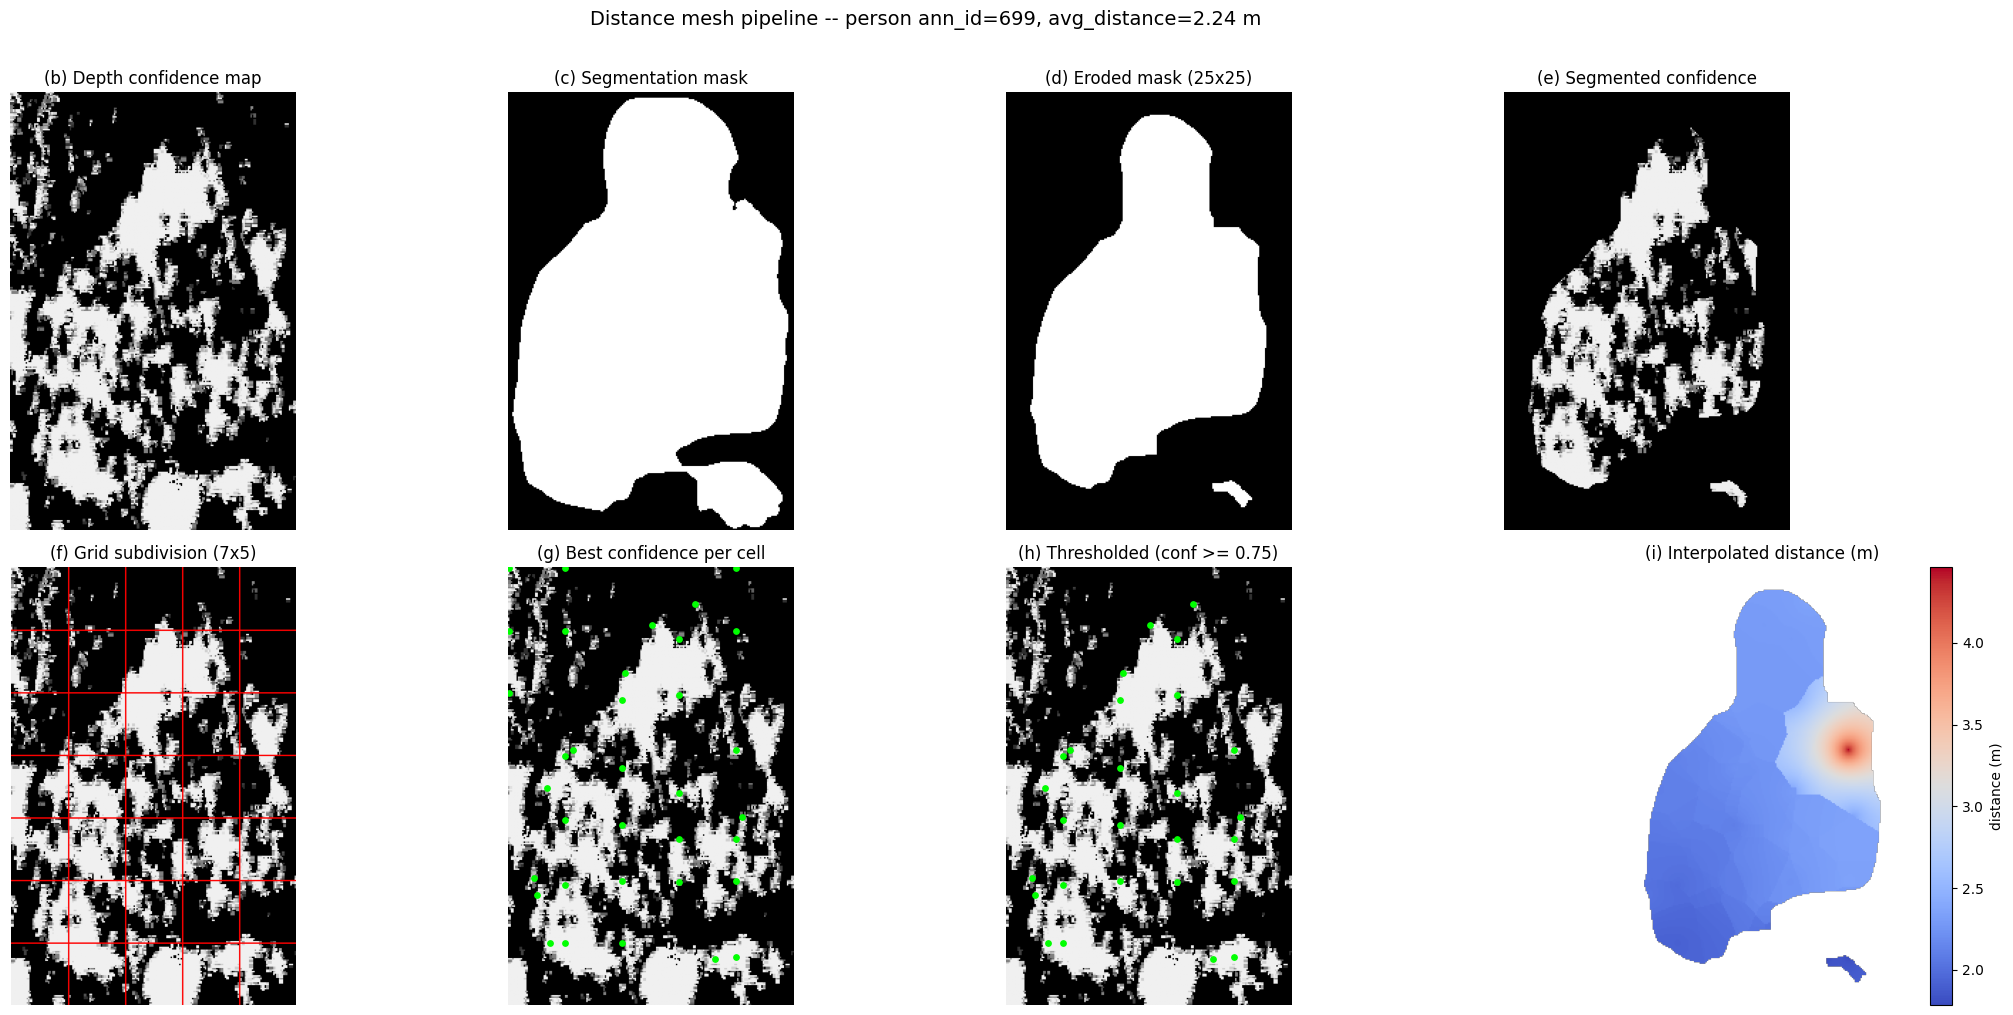

In [4]:
import json
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from math import floor, ceil
from kornia.morphology import erosion as kornia_erosion
from nerve.extraction.utils.depth_utils import extract_depth_points, retrieve_distance

ann_path = session_dir / "rgb" / "annotations" / "annotations.json"
coco = json.loads(ann_path.read_text(encoding="utf-8"))

print("images:", len(coco.get("images", [])))
print("annotations:", len(coco.get("annotations", [])))
print("categories:", [c["name"] for c in coco.get("categories", [])])

dists = [a["avg_distance"] for a in coco["annotations"]
         if "avg_distance" in a and a["avg_distance"] is not None]
if not dists:
    print("\nNo avg_distance fields found")
else:
    d = np.array(dists, dtype=float)
    print(f"\navg_distance count: {len(d)}")
    print(f"  min / max / mean (m): {d.min():.2f} / {d.max():.2f} / {d.mean():.2f}")
    print(f"  median (m): {np.median(d):.2f}")

n_dp = sum(1 for a in coco["annotations"] if a.get("distance_points"))
print(f"annotations with distance_points: {n_dp}")

# ── Pick the largest person annotation ──
img_by_id = {i["id"]: i for i in coco["images"]}
cat_by_id = {c["id"]: c["name"] for c in coco["categories"]}

best_ann, best_area = None, 0
for ann in coco["annotations"]:
    if cat_by_id.get(ann["category_id"]) == "person":
        _, _, w, h = ann["bbox"]
        if w * h > best_area:
            best_area = w * h
            best_ann = ann
if best_ann is None:
    best_ann = coco["annotations"][0]

img_entry = img_by_id[best_ann["image_id"]]
time_ms = img_entry["time_ms"]
frame_h, frame_w = img_entry["height"], img_entry["width"]

# ── Read depth unit, depth frame, and confidence frame ──
depth_unit_file = session_dir / "L515_depth_unit.txt"
depth_unit = float(depth_unit_file.read_text().strip()) if depth_unit_file.is_file() else 0.000250

depth_mp4 = session_dir / "L515_depth.mp4"
cap_d = cv2.VideoCapture(str(depth_mp4))
depth_fps = cap_d.get(cv2.CAP_PROP_FPS)
depth_frame_idx = int(round(time_ms * depth_fps / 1000.0))
cap_d.set(cv2.CAP_PROP_POS_FRAMES, depth_frame_idx)
ok_d, depth_bgr = cap_d.read()
cap_d.release()
assert ok_d, f"Could not read depth frame {depth_frame_idx}"

conf_mp4 = session_dir / "L515_depth_confidence.mp4"
cap_c = cv2.VideoCapture(str(conf_mp4))
conf_fps = cap_c.get(cv2.CAP_PROP_FPS)
conf_frame_idx = int(round(time_ms * conf_fps / 1000.0))
cap_c.set(cv2.CAP_PROP_POS_FRAMES, conf_frame_idx)
ok_c, conf_bgr = cap_c.read()
cap_c.release()
assert ok_c, f"Could not read confidence frame {conf_frame_idx}"

device = torch.device("cpu")
depth_frame = torch.from_numpy(
    cv2.cvtColor(depth_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32) * depth_unit * 255
).to(device)
conf_frame = torch.from_numpy(
    cv2.cvtColor(conf_bgr, cv2.COLOR_BGR2GRAY)
).to(device)
DEPTH_CONF_MAX = 255.0

# ── Build the segmentation mask from the COCO polygon ──
seg_np = np.zeros((frame_h, frame_w), dtype=np.uint8)
for seg_poly in best_ann.get("segmentation", []):
    pts = np.array(seg_poly, dtype=np.int32).reshape(-1, 2)
    cv2.fillPoly(seg_np, [pts], 1)
seg_mask = torch.from_numpy(seg_np).float().to(device)

# ── (d) Eroded mask -- kornia erosion, same 25x25 kernel as label_extractor ──
eroded_mask = kornia_erosion(
    seg_mask.unsqueeze(0).unsqueeze(0),
    torch.ones(25, 25, device=device)
)[0, 0].bool()

# ── avg_distance: confidence-weighted mean of depth inside eroded mask ──
confs_int = conf_frame[eroded_mask]
if confs_int.sum() == 0:
    avg_depth = -1.0
else:
    confs_norm = confs_int.float() / DEPTH_CONF_MAX
    avg_depth = float((depth_frame[eroded_mask] @ confs_norm) / confs_norm.sum())
print(f"\nRecomputed avg_distance: {avg_depth:.4f} m  "
      f"(stored: {best_ann.get('avg_distance', 'N/A')})")

# ── Crop to bounding box (same as label_extractor lines 327-365) ──
bx, by, bw, bh = best_ann["bbox"]
min_x, max_x = floor(bx), ceil(bx + bw)
min_y, max_y = floor(by), ceil(by + bh)

norm_conf = conf_frame.float() / DEPTH_CONF_MAX
cropped_mask  = eroded_mask[min_y:max_y+1, min_x:max_x+1]
cropped_conf  = norm_conf[min_y:max_y+1, min_x:max_x+1]
cropped_depth = depth_frame[min_y:max_y+1, min_x:max_x+1]

PIX_WINDOW = 40
CONF_THRESHOLD = 0.75
grid = (max(1, cropped_conf.shape[0] // PIX_WINDOW),
        max(1, cropped_conf.shape[1] // PIX_WINDOW))

# ── (f/g) Grid subdivision + best-confidence per cell ──
all_points = extract_depth_points(grid, cropped_mask, cropped_conf, cropped_depth)

# ── (h) Threshold on confidence ──
kept_points = all_points[all_points[:, 2] >= CONF_THRESHOLD]
kept_points[:, 0] += min_x
kept_points[:, 1] += min_y

# Strip confidence column to get (x, y, distance) -- same as label_extractor
distance_mesh = torch.cat((kept_points[:, :2], kept_points[:, 3:]), dim=-1)

# ── (i) Interpolated distance heatmap using retrieve_distance ──
ys_grid, xs_grid = torch.meshgrid(
    torch.arange(cropped_depth.shape[0], dtype=torch.float32),
    torch.arange(cropped_depth.shape[1], dtype=torch.float32),
    indexing="ij")
pixel_centers = torch.stack([xs_grid.reshape(-1) + min_x,
                              ys_grid.reshape(-1) + min_y], dim=-1)
if len(distance_mesh) >= 4:
    interp_flat = retrieve_distance(pixel_centers, distance_mesh)
    interp_map = interp_flat.reshape(cropped_depth.shape).cpu().numpy()
    interp_map[~cropped_mask.cpu().numpy().astype(bool)] = np.nan
else:
    interp_map = np.full(cropped_depth.shape[:2], np.nan)

# ── Visualise the 2x4 pipeline (mirrors thesis Fig 4.14, without RGB subfigure a) ──
seg_conf_np = (norm_conf * eroded_mask.float()).cpu().numpy()
cropped_conf_np = cropped_conf.cpu().numpy()
all_pts_np = all_points.cpu().numpy()
kept_pts_np = kept_points.cpu().numpy()

cell_h = cropped_conf.shape[0] // grid[0]
cell_w = cropped_conf.shape[1] // grid[1]
trimmed_h, trimmed_w = cell_h * grid[0], cell_w * grid[1]
grid_vis = cropped_conf_np[:trimmed_h, :trimmed_w].copy()

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax in axes.ravel():
    ax.axis("off")

axes[0, 0].imshow(conf_frame.cpu().numpy()[min_y:max_y+1, min_x:max_x+1],
                   cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("(b) Depth confidence map")

axes[0, 1].imshow(seg_np[min_y:max_y+1, min_x:max_x+1], cmap="gray")
axes[0, 1].set_title("(c) Segmentation mask")

axes[0, 2].imshow(eroded_mask.cpu().numpy()[min_y:max_y+1, min_x:max_x+1], cmap="gray")
axes[0, 2].set_title("(d) Eroded mask (25x25)")

axes[0, 3].imshow(seg_conf_np[min_y:max_y+1, min_x:max_x+1], cmap="gray", vmin=0, vmax=1)
axes[0, 3].set_title("(e) Segmented confidence")

grid_rgb = np.stack([grid_vis] * 3, axis=-1)
for i in range(1, grid[1]):
    grid_rgb[:, i * cell_w, :] = [1, 0, 0]
for i in range(1, grid[0]):
    grid_rgb[i * cell_h, :, :] = [1, 0, 0]
axes[1, 0].imshow(grid_rgb)
axes[1, 0].set_title(f"(f) Grid subdivision ({grid[0]}x{grid[1]})")

axes[1, 1].imshow(cropped_conf_np, cmap="gray", vmin=0, vmax=1)
for i in range(1, grid[1]):
    axes[1, 1].axvline(i * cell_w, color="red", linewidth=0.5)
for i in range(1, grid[0]):
    axes[1, 1].axhline(i * cell_h, color="red", linewidth=0.5)
axes[1, 1].scatter(all_pts_np[:, 0], all_pts_np[:, 1], c="lime", s=15, zorder=5)
axes[1, 1].set_title("(g) Best confidence per cell")

axes[1, 2].imshow(cropped_conf_np, cmap="gray", vmin=0, vmax=1)
for i in range(1, grid[1]):
    axes[1, 2].axvline(i * cell_w, color="red", linewidth=0.5)
for i in range(1, grid[0]):
    axes[1, 2].axhline(i * cell_h, color="red", linewidth=0.5)
if len(kept_pts_np):
    axes[1, 2].scatter(kept_pts_np[:, 0] - min_x, kept_pts_np[:, 1] - min_y,
                       c="lime", s=15, zorder=5)
axes[1, 2].set_title(f"(h) Thresholded (conf >= {CONF_THRESHOLD})")

im = axes[1, 3].imshow(interp_map, cmap="coolwarm")
for i in range(1, grid[1]):
    axes[1, 3].axvline(i * cell_w, color="red", linewidth=0.5)
for i in range(1, grid[0]):
    axes[1, 3].axhline(i * cell_h, color="red", linewidth=0.5)
axes[1, 3].set_title("(i) Interpolated distance (m)")
cbar = fig.colorbar(im, ax=axes[1, 3], fraction=0.046, pad=0.04)
cbar.set_label("distance (m)")

cat_name = cat_by_id.get(best_ann["category_id"], "?")
fig.suptitle(
    f"Distance mesh pipeline -- {cat_name} ann_id={best_ann['id']}"
    + (f", avg_distance={avg_depth:.2f} m" if avg_depth > 0 else ""),
    fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Track IDs -- temporal consistency

When `track_id` is set, the same physical instance keeps a stable identifier across frames within a session, which is useful for video-level training and evaluation.

---
## Live demo: running the label extractor on an example video

The `nerve.extraction.label_extractor` module takes any RGB video and produces
a COCO-format `annotations.json` with detection bounding boxes, instance
segmentation masks, pose keypoints, and track IDs.

Below we run it on a short example clip (`people-detection.mp4`) using
YOLOv8-nano models on CPU, then visualize the output.


In [8]:
import subprocess, shutil
from pathlib import Path

example_video = Path("example_input_video/people-detection.mp4").resolve()
output_dir = Path("example_input_video/output").resolve()

if output_dir.exists():
    shutil.rmtree(output_dir)

# Run the NERVE label extractor module -- same pipeline used for all dataset annotations.
# Flags: --seg-model / --pose-model  select YOLOv8 variants;
#        --device cpu                runs on CPU (use "0" for GPU);
#        --perform-human-seg ""      skips body-part segmentation (needs extra weights).
cmd = [
    "python", "-m", "nerve.extraction.label_extractor",
    "--target-video", str(example_video),
    "--output-dir",   str(output_dir),
    "--seg-model",    "yolov8n-seg.pt",
    "--pose-model",   "yolov8n-pose.pt",
    "--device",       "cpu",
    "--perform-human-seg", "",
]
print("Running:", " ".join(cmd))
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)
    raise RuntimeError(f"Label extractor exited with code {result.returncode}")

ann_file = output_dir / "annotations" / "annotations.json"
coco_out = json.loads(ann_file.read_text(encoding="utf-8"))
print(f"Output: {len(coco_out['images'])} images, "
      f"{len(coco_out['annotations'])} annotations")

Running: python -m nerve.extraction.label_extractor --target-video /gpfs/home5/omansour/nerve/walkthroughs/example_input_video/people-detection.mp4 --output-dir /gpfs/home5/omansour/nerve/walkthroughs/example_input_video/output --seg-model yolov8n-seg.pt --pose-model yolov8n-pose.pt --device cpu --perform-human-seg 

fps: 12.0; totalFrames: 596
original dimensions:  432 x 768 ; padded dimensions:  448 x 768
Created 468 annotations.

Output: 596 images, 468 annotations


### Visualize extracted annotations

We load the generated `annotations.json`, pick a frame with multiple
detections, and overlay bounding boxes, segmentation contours,
COCO-17 pose skeletons, and track IDs on the original video frame.


Generated: 596 images, 468 annotations, 80 categories
Showing frame 372 with 4 annotations


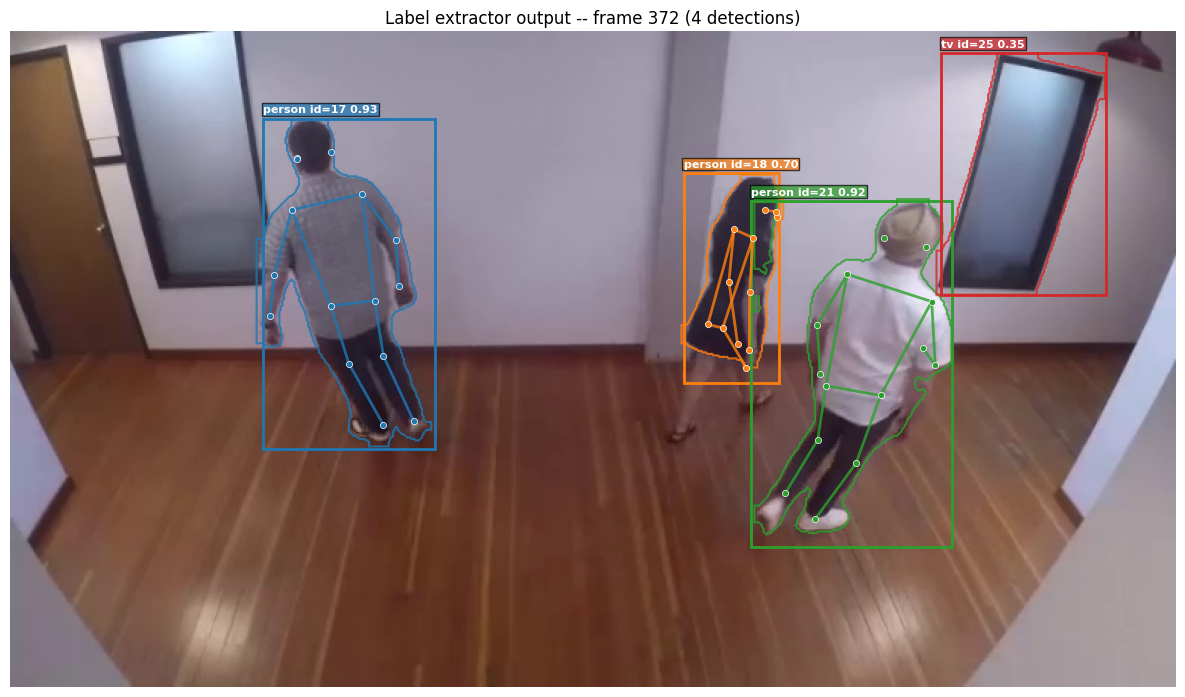

In [9]:
import cv2

demo_ann_path = output_dir / "annotations" / "annotations.json"
demo_coco = json.loads(demo_ann_path.read_text(encoding="utf-8"))
print(f"Generated: {len(demo_coco['images'])} images, "
      f"{len(demo_coco['annotations'])} annotations, "
      f"{len(demo_coco['categories'])} categories")

cat_by_id = {c["id"]: c["name"] for c in demo_coco["categories"]}
img_by_id = {i["id"]: i for i in demo_coco["images"]}

# Group annotations by image_id and pick the frame with the most detections
from collections import Counter
ann_counts = Counter(a["image_id"] for a in demo_coco["annotations"])
best_frame_id = ann_counts.most_common(1)[0][0]
frame_anns = [a for a in demo_coco["annotations"] if a["image_id"] == best_frame_id]
print(f"Showing frame {best_frame_id} with {len(frame_anns)} annotations")

# Read the actual video frame
cap = cv2.VideoCapture(str(example_video))
cap.set(cv2.CAP_PROP_POS_FRAMES, best_frame_id)
ok, frame_bgr = cap.read()
cap.release()
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

EDGES = [
    (0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
    (5, 11), (6, 12), (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),
]
COLORS = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(frame_rgb)

for idx, ann in enumerate(frame_anns):
    color = COLORS[idx % len(COLORS)]
    bx, by, bw, bh = ann["bbox"]
    ax.add_patch(patches.Rectangle((bx, by), bw, bh,
                 fill=False, edgecolor=color, linewidth=2))

    cat = cat_by_id.get(ann["category_id"], "?")
    tid = ann.get("track_id", -1)
    conf = ann.get("conf", 0)
    ax.text(bx, by - 4, f"{cat} id={tid} {conf:.2f}",
            color="white", fontsize=8, weight="bold",
            bbox=dict(facecolor=color, alpha=0.7, pad=1))

    # Segmentation contours
    for seg in ann.get("segmentation", []):
        pts = np.array(seg).reshape(-1, 2)
        poly = plt.Polygon(pts, fill=False, edgecolor=color, linewidth=1.5, alpha=0.8)
        ax.add_patch(poly)

    # Pose keypoints
    kps = ann.get("keypoints")
    if kps and len(kps) >= 3:
        kps = np.array(kps, dtype=float).reshape(-1, 3)
        for i, j in EDGES:
            if kps[i, 2] > 0.3 and kps[j, 2] > 0.3:
                ax.plot([kps[i, 0], kps[j, 0]], [kps[i, 1], kps[j, 1]],
                        "-", color=color, linewidth=2, alpha=0.8)
        vis = kps[:, 2] > 0.3
        ax.scatter(kps[vis, 0], kps[vis, 1], c=[color], s=20,
                   edgecolors="white", linewidths=0.5, zorder=5)

ax.set_title(f"Label extractor output -- frame {best_frame_id} "
             f"({len(frame_anns)} detections)")
ax.axis("off")
plt.tight_layout()
plt.show()
